In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

import importlib

import tensorboard
%load_ext tensorboard

import math

from torch.utils.tensorboard import SummaryWriter
import datetime

import os, sys
module_path = os.path.abspath(os.path.join('..', "source"))
if module_path not in sys.path:
    sys.path.append(module_path)

import pbr_dataset
import models
import train

import torchmetrics
import flip_loss

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

## Tensorboard
This command gets you tensorboard with all the metrics and data. Run it in a command line in the notebook directory if you want it on its own tab. 
### Warning
I would recommend just running the command in a command prompt because I don't know how to close the server from a notebook.

In [2]:
tensorboard.notebook.list()

Known TensorBoard instances:
  - port 6006: logdir ../experiments/pbr_compression (started 0:29:09 ago; pid 34696)


In [14]:
tensorboard.notebook.start("--logdir ../experiments/pbr_compression --samples_per_plugin images=500")

## Loading the PBR textures
For now I'm just going to assume that each pbr material has a texture folder and there are three textures named 'arm.jpg', 'albedo.jpg' and 'normal.jpg'.

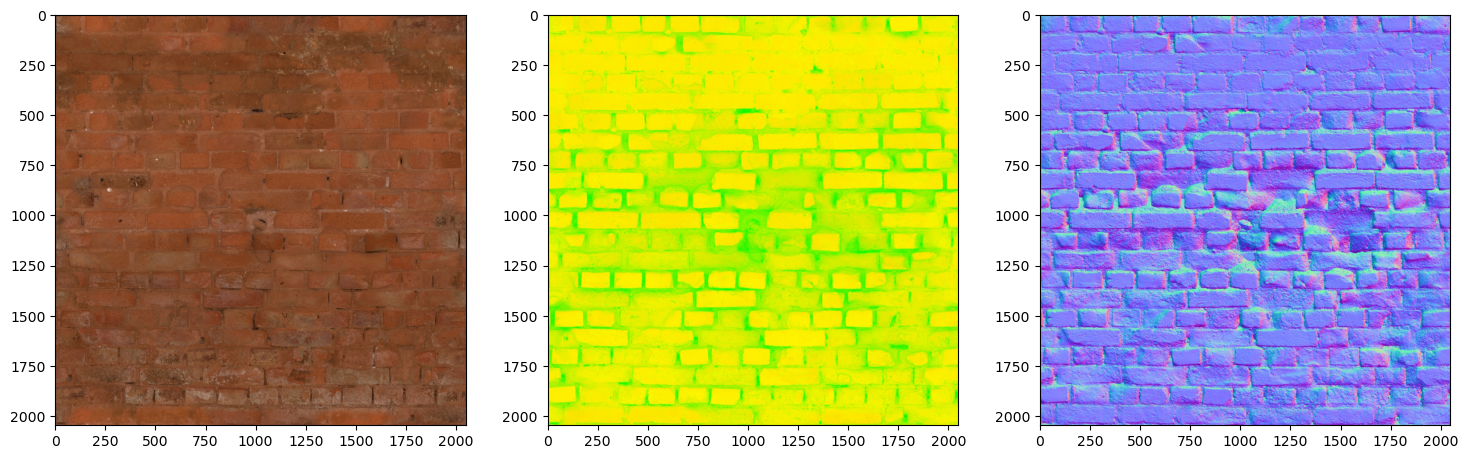

In [2]:
materials_path = "../assets/materials/"
material_name = "broken_brick_wall"
material_textures_path = materials_path + material_name + "/textures/"
ext = ".jpg"

albedo = Image.open(material_textures_path + "albedo" + ext).convert("RGB")
arm = Image.open(material_textures_path + "arm" + ext).convert("RGB")
normal = Image.open(material_textures_path + "normal" + ext).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(albedo)
axes[1].imshow(arm)
axes[2].imshow(normal)

plt.show()

In [3]:
if 'writer' in globals():
    writer.close()
    del writer
    
writer = SummaryWriter("../experiments/pbr_compression/siren" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

hidden_features = 64 
hidden_layers = 3
first_omega = 30
hidden_omega = 30

model = models.Siren(in_features=2, out_features=3*3, hidden_features=hidden_features, hidden_layers=hidden_layers, 
                     first_omega_0=first_omega, hidden_omega_0=hidden_omega).cuda()

sidelength = 512
batch_size = 512
dataset = pbr_dataset.PBRDataset(albedo, arm, normal, sidelength=sidelength)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

writer.add_graph(model.net, dataset.input_features_tensor)
writer.add_text("model info", f"sidelength: {sidelength}\nbatch size: {batch_size}\nhidden features: {hidden_features}\nhidden layers: {hidden_layers}\nfirst omega: {first_omega}\nhidden omega: {hidden_omega}")

current_epoch = 0

C:\Users\avree\miniforge3\envs\ml\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\bld\libtorch_1753839109265\work\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


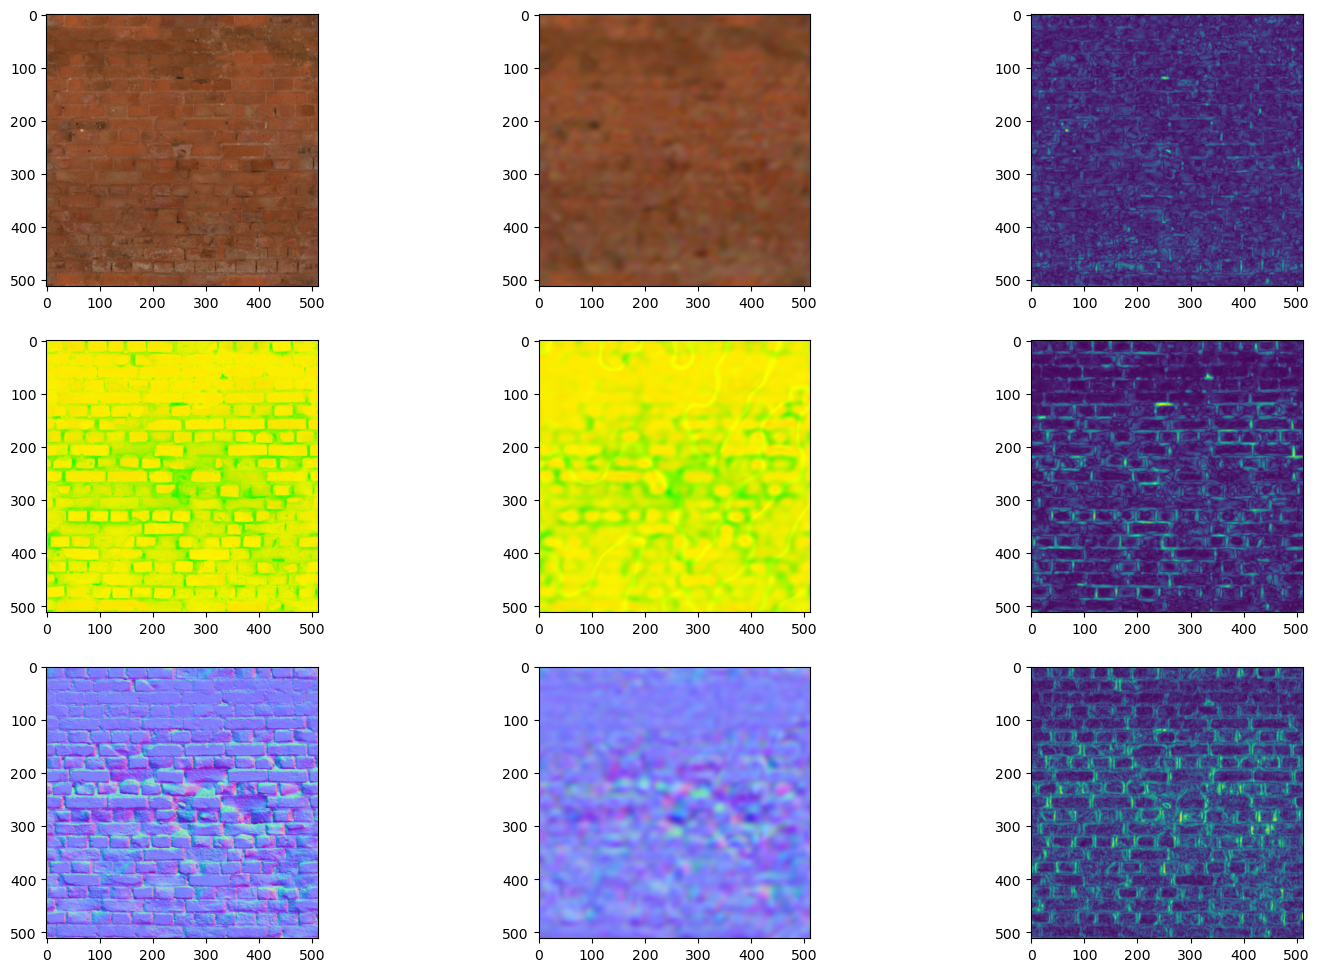

epoch:  10


In [5]:
importlib.reload(models)
importlib.reload(train)

optimizer = torch.optim.Adam(lr=1e-4, params=model.parameters())

loss_fn = torch.nn.L1Loss()

num_epochs = 5

train.training_loop(model, optimizer, dataloader, writer, loss_fn, num_epochs, current_epoch, 20)
current_epoch = current_epoch + num_epochs